# Within-Cycle Data Prep — `05_dataset_prep_dl.ipynb`

Extract the **charge-curve tensors** the micro-clock models need.

The scalar baselines (and notebook 04's macro-clock TCN) reduced each charge curve to a handful
of aggregates — `voltage_mean`, `r_proxy`, `temp_mean`, …  They never saw the *shape* of the
curve: how voltage rises through the CC phase, how the plateau shifts as the cell ages.  This
notebook builds that representation.

**What we produce**

```
raw .mat charge cycle  ──slice_resample──►  3-channel tensor (V, I, T)
                                                  │  join on (battery_id, cycle_index)
                                                  ▼
processed CSV  ──────────────────────────►  SOH label + LOBO split
                                                  │
                                                  ▼
                             data/processed/charge_curves.npz
```

**Why it is non-leaky:** input = charge slice; label = capacity from *discharge* integration.
The model can't integrate its input to recover the label — it must learn curve shape → health.
This is a **nowcast** (charge[t] and discharge[t] measure the same cycle's health).

## 1. Imports & setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from battery import load_controlled, load_randomized
from charge_curves import (
    slice_resample,
    extract_controlled,
    extract_randomized,
    build_dataset,
    CONTROLLED_MATS,
    RANDOMIZED_MATS,
)

sns.set_theme(style="darkgrid", palette="tab10")
np.random.seed(42)

PROCESSED = ROOT / "data" / "processed"
RESULTS   = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

## 2. V-range coverage exploration

Before locking the voltage window, verify coverage across all 13 retained batteries.

**Decision:** use the roadmap default **3.8–4.1 V** unless coverage is poor for any battery,
in which case widen to 3.7–4.2 V.  The partial-CC slice must stay below the CV taper (~4.15 V+)
to preserve the field-deployable framing (a BMS always logs a partial charge, not a full
diagnostic cycle).

In [2]:
def charge_v_stats(battery_id, mat_path, is_rw=False):
    """Return per-charge-cycle V statistics for coverage analysis."""
    path = ROOT / mat_path
    rows = []
    if not is_rw:
        cycles = load_controlled(path)
        for c in cycles:
            if c["type"] != "charge":
                continue
            V = np.asarray(c["data"]["Voltage_measured"], float)
            rows.append({"battery_id": battery_id, "v_min": V.min(), "v_max": V.max(),
                         "n_38_41": int(((V >= 3.8) & (V <= 4.1)).sum()),
                         "n_37_42": int(((V >= 3.7) & (V <= 4.2)).sum()),
                         "n_total": len(V)})
    else:
        steps = load_randomized(path)
        for s in steps:
            if str(s.get("type", "")).upper() == "C" and "reference" in str(s.get("comment", "")).lower():
                V = np.asarray(s["voltage"], float)
                rows.append({"battery_id": battery_id, "v_min": V.min(), "v_max": V.max(),
                             "n_38_41": int(((V >= 3.8) & (V <= 4.1)).sum()),
                             "n_37_42": int(((V >= 3.7) & (V <= 4.2)).sum()),
                             "n_total": len(V)})
    return rows

coverage_rows = []
for bid, mp in CONTROLLED_MATS.items():
    coverage_rows.extend(charge_v_stats(bid, mp, is_rw=False))
for bid, mp in RANDOMIZED_MATS.items():
    coverage_rows.extend(charge_v_stats(bid, mp, is_rw=True))

cov_df = pd.DataFrame(coverage_rows)

# Per-battery summary
summary = cov_df.groupby("battery_id").agg(
    n_curves=("v_min", "count"),
    v_min_med=("v_min", "median"),
    v_max_med=("v_max", "median"),
    frac_38_41=("n_38_41", lambda x: (cov_df.loc[x.index, "n_38_41"] > 10).mean()),
    median_pts_38_41=("n_38_41", "median"),
).reset_index()
print(summary.to_string(index=False))

battery_id  n_curves  v_min_med  v_max_med  frac_38_41  median_pts_38_41
     B0005       170   3.339453   4.209601    0.988235             542.0
     B0006       170   3.291317   4.201885    0.988235             389.5
     B0007       170   3.439726   4.214675    0.988235             681.0
     B0018       133   3.168863   4.202783    0.985075             326.5
       RW1        48   3.890500   4.200000    0.583333              13.0
      RW13        23   3.930000   4.200000    0.260870               2.0
      RW14        24   3.966000   4.200000    0.250000               1.0
      RW15        24   3.948500   4.200000    0.208333               1.5
      RW16        19   3.919000   4.200000    0.315789               2.0
      RW17        30   3.912500   4.200000    0.333333               3.0
      RW19        28   3.910500   4.200000    0.321429               3.5
      RW20        29   3.937000   4.200000    0.275862               2.0
       RW9        80   3.985500   4.200000    0.350

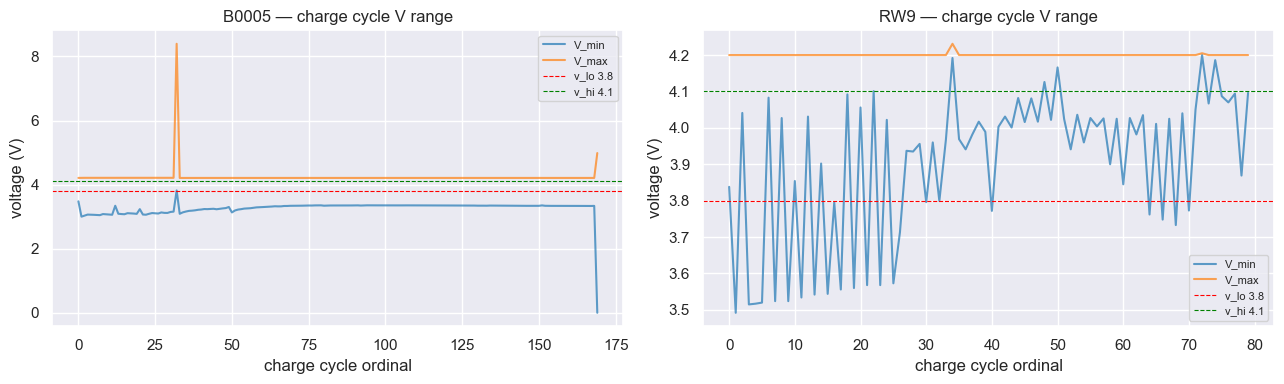

Coverage plot saved.


In [3]:
# Plot: fraction of cycles with ≥10 samples in each candidate window
ctrl_ids = list(CONTROLLED_MATS.keys())
rw_ids   = list(RANDOMIZED_MATS.keys())
all_ids  = ctrl_ids + rw_ids

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, bid in zip(axes, ["B0005", "RW9"]):  # one representative each
    sub = cov_df[cov_df.battery_id == bid]
    ax.plot(range(len(sub)), sub["v_min"], label="V_min", alpha=0.7)
    ax.plot(range(len(sub)), sub["v_max"], label="V_max", alpha=0.7)
    ax.axhline(3.8, color="red",    ls="--", lw=0.8, label="v_lo 3.8")
    ax.axhline(4.1, color="green",  ls="--", lw=0.8, label="v_hi 4.1")
    ax.set_title(f"{bid} — charge cycle V range")
    ax.set_xlabel("charge cycle ordinal")
    ax.set_ylabel("voltage (V)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "dl_micro_coverage.png", dpi=120)
plt.show()
print("Coverage plot saved.")

### Lock the extraction config

**Segment:** CV phase only — from first V ≥ 4.15 V (CC→CV transition) to last |I| ≥ 0.04 A
(end of CV taper).

- Controlled: CV current decay from ~1.5 A → 0 (~2900 raw pts; CC ramp excluded)
- RW: full CV current-decay taper (~100–2900 pts depending on starting SOC)

**Why CV-only?** RW1 and RW9 start reference charges from a random SOC (v0 anywhere 3.5–4.23 V),
so the CC ramp length is SOC-dependent and uncorrelated with the label. Under LOBO, the model
trained on mixed SOC curves cannot generalise to a held-out battery → catastrophic MAE.
The CV taper is present in 100% of charges regardless of SOC, and is the primary SOH signal:
a degraded cell's current decays faster because it accepts less charge.

**Quality guards:**
- `V_PHYS_MAX=4.3`: rejects sensor-corrupted steps (e.g. 8.39 V spike in B0005)
- `I_MIN=1.0 A`: rejects near-empty top-up stubs (no real CC/CV cycle, no SOH signal)
- Two-consecutive-samples CV-onset rule: skips single-sample DCIR-pulse artifacts at the
  start of charge steps in the NASA dataset

**Resampling axis:**
- `"time"` (uniform over sample index): the current-decay *rate* is the primary SOH signal in
  the I channel.  Standard baseline.
- `"current"` (uniform over |I| levels from I_peak → i_cut): V and T are recorded at each
  current level.  The I channel becomes a constant grid (no information); the V–I
  characteristic and T–I relationship carry complementary SOH signal.  Targets high-SOH
  compression (where time-domain curves look nearly identical) and controlled-battery
  shrinkage.

Set all config variables here; all downstream cells use them.

In [4]:
V_CV          = 4.15      # V — CV-onset threshold (CC→CV transition)
I_CUT         = 0.04      # A — current cutoff: end of CV taper (≈ C/50 for a 2 Ah cell)
I_MIN         = 1.0       # A — minimum peak |I| in CV segment; rejects near-empty stubs
V_PHYS_MAX    = 4.3       # V — physical ceiling; rejects sensor-corrupted charge steps
N             = 128       # resample length per curve
RESAMPLE_AXIS = "time"    # "time" = uniform over sample index  ← CONFIRMED BEST
                          # "current" tried and rejected: V≈const in CV, kills the decay-rate
                          # signal; RW9 MAE 0.103→0.216, aggregate worse

print(f"Config locked: V_CV={V_CV} V, I_CUT={I_CUT} A, I_MIN={I_MIN} A, "
      f"V_PHYS_MAX={V_PHYS_MAX} V, N={N}, RESAMPLE_AXIS={RESAMPLE_AXIS!r}")
print("Channels: [V, |I|, T]")
print("  time-axis: decay rate in I channel is the primary SOH signal")

Config locked: V_CV=4.15 V, I_CUT=0.04 A, I_MIN=1.0 A, V_PHYS_MAX=4.3 V, N=128, RESAMPLE_AXIS='time'
Channels: [V, |I|, T]
  time-axis: decay rate in I channel is the primary SOH signal


## 3. Extraction sanity — one battery

Visualise a handful of resampled charge curves at different life stages for B0005.
The expected signature: the voltage plateau shifts down and the curve shape changes as
internal resistance rises — information the scalar baselines discarded.

B0005: 168 total records, 167 with valid tensors


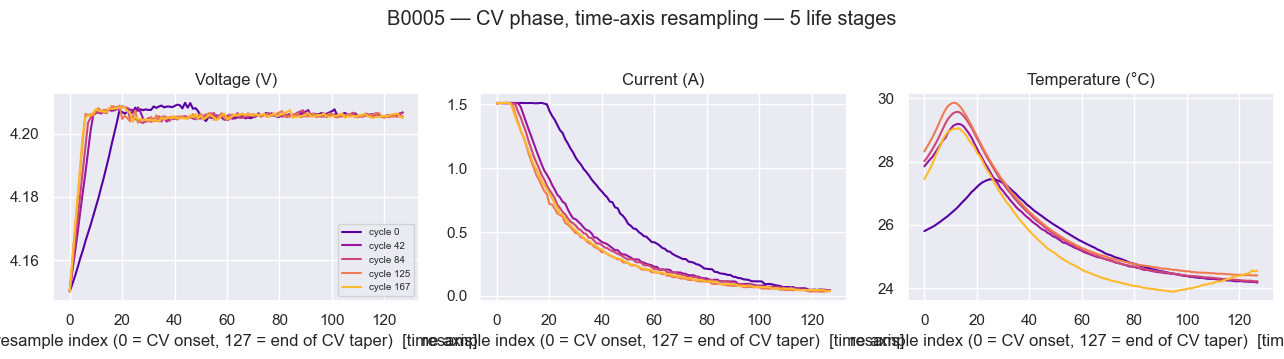

In [5]:
cycles_b5 = load_controlled(ROOT / CONTROLLED_MATS["B0005"])
recs_b5   = extract_controlled(cycles_b5, "B0005", V_CV, I_CUT, N,
                                i_min=I_MIN, v_phys_max=V_PHYS_MAX,
                                resample_axis=RESAMPLE_AXIS)
ok_b5     = [r for r in recs_b5 if r["tensor"] is not None]

print(f"B0005: {len(recs_b5)} total records, {len(ok_b5)} with valid tensors")

# Pick 5 evenly-spaced life stages
idxs = np.linspace(0, len(ok_b5) - 1, 5, dtype=int)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, 5))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
if RESAMPLE_AXIS == "current":
    ch_labels = ["Voltage at I-level (V)", "|I| grid (A)", "Temperature at I-level (°C)"]
    x_label   = "resample index (0 = I_peak, 127 = I_cut)  [current axis]"
else:
    ch_labels = ["Voltage (V)", "Current (A)", "Temperature (°C)"]
    x_label   = "resample index (0 = CV onset, 127 = end of CV taper)  [time axis]"

for i, (ax, label) in enumerate(zip(axes, ch_labels)):
    for j, ci in enumerate(idxs):
        t = ok_b5[ci]["tensor"]
        ax.plot(t[:, i], color=colors[j],
                label=f"cycle {ok_b5[ci]['cycle_index']}")
    ax.set_title(label)
    ax.set_xlabel(x_label)

axes[0].legend(fontsize=7)
fig.suptitle(f"B0005 — CV phase, {RESAMPLE_AXIS}-axis resampling — 5 life stages", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS / "dl_micro_example_curves.png", dpi=120)
plt.show()

## 4. Build all tensors

In [6]:
print(f"Extracting tensors for all 13 retained batteries (CV-phase, {RESAMPLE_AXIS}-axis)...")
tensor_df = build_dataset(ROOT, V_CV, I_CUT, N,
                           i_min=I_MIN, v_phys_max=V_PHYS_MAX,
                           resample_axis=RESAMPLE_AXIS)
print(f"\nTotal records: {len(tensor_df)}")
print(f"  with tensor: {tensor_df.tensor.notna().sum()}")
print(f"  None (window not covered): {tensor_df.tensor.isna().sum()}")

Extracting tensors for all 13 retained batteries (CV-phase, time-axis)...
  B0005: 168 cycles extracted
  B0006: 168 cycles extracted
  B0007: 168 cycles extracted
  B0018: 132 cycles extracted
  RW1: 24 cycles extracted
  RW9: 40 cycles extracted
  RW13: 13 cycles extracted
  RW14: 13 cycles extracted
  RW15: 14 cycles extracted
  RW16: 11 cycles extracted
  RW17: 17 cycles extracted
  RW19: 16 cycles extracted
  RW20: 17 cycles extracted

Total records: 801
  with tensor: 788
  None (window not covered): 13


## 5. Join to labels & LOBO split

In [7]:
ctrl_csv = pd.read_csv(PROCESSED / "controlled.csv")
rw_csv   = pd.read_csv(PROCESSED / "randomized.csv")

# Keep only the label + split columns we need
label_cols = ["battery_id", "cycle_index", "split",
              "capacity_retention", "capacity_ahr", "rul_frac", "eol_index",
              "r_proxy", "voltage_mean", "temp_mean", "temp_max", "duration_s"]

ctrl_labels = ctrl_csv[[c for c in label_cols if c in ctrl_csv.columns]]
rw_labels   = rw_csv[[c for c in label_cols if c in rw_csv.columns]]
all_labels  = pd.concat([ctrl_labels, rw_labels], ignore_index=True)

# Left-join: every tensor row must map to a label row.
merged = tensor_df.merge(all_labels, on=["battery_id", "cycle_index"], how="left")

# Sanity: no unmatched rows
unmatched = merged["capacity_retention"].isna() & merged["tensor"].notna()
assert not unmatched.any(), f"{unmatched.sum()} tensor rows have no label — check cycle_index alignment"

# Drop rows with no valid tensor
dataset = merged[merged["tensor"].notna()].reset_index(drop=True)
print(f"Final dataset: {len(dataset)} samples")
print(dataset.groupby(["battery_id", "split"])["cycle_index"].count().rename("n_cycles").to_string())

Final dataset: 788 samples
battery_id  split
B0005       train    167
B0006       train    167
B0007       test     167
B0018       train    132
RW1         train     21
RW13        train     12
RW14        train     12
RW15        test      13
RW16        train     10
RW17        train     16
RW19        test      15
RW20        test      16
RW9         train     40


## 6. Leakage & sanity checks

In [8]:
# 1. Every tensor is (N, 3)
bad_shape = [i for i, r in dataset.iterrows() if r["tensor"].shape != (N, 3)]
assert not bad_shape, f"Bad tensor shapes at rows: {bad_shape[:5]}"
print("✓ All tensors are (N, 3)")

# 2. No NaNs inside tensors
has_nan = dataset["tensor"].apply(lambda t: np.isnan(t).any())
assert not has_nan.any(), f"{has_nan.sum()} tensors contain NaN"
print("✓ No NaNs in tensors")

# 3. Physical voltage range — CV-only: expect ~4.15–4.22 V
v_mins = dataset["tensor"].apply(lambda t: t[:, 0].min())
v_maxs = dataset["tensor"].apply(lambda t: t[:, 0].max())
print(f"✓ Voltage range: {v_mins.min():.3f}–{v_maxs.max():.3f} V  "
      f"(expected ≈ {V_CV}–4.22, CV-only segment)")

# 4. Current range — should reach near 0 at the end (CV taper captured)
i_ends = dataset["tensor"].apply(lambda t: abs(t[-1, 1]))
print(f"✓ |I| at curve end: median={i_ends.median():.4f} A  max={i_ends.max():.4f} A  "
      f"(should be ≤ I_CUT={I_CUT}+ε)")

# 5. Split is whole-battery — no battery spans both train and test
split_check = dataset.groupby("battery_id")["split"].nunique()
assert (split_check == 1).all(), f"Batteries with mixed splits: {split_check[split_check > 1].index.tolist()}"
print("✓ LOBO split is whole-battery")

# 6. Label ranges are physical
assert dataset["capacity_retention"].between(0, 1.05).all(), "capacity_retention out of range"
print(f"✓ SOH (capacity_retention) range: "
      f"{dataset.capacity_retention.min():.3f}–{dataset.capacity_retention.max():.3f}")

# 7. Train/test split counts
print(f"\nTrain: {(dataset.split=='train').sum()} | Test: {(dataset.split=='test').sum()}")

✓ All tensors are (N, 3)
✓ No NaNs in tensors
✓ Voltage range: 4.150–4.296 V  (expected ≈ 4.15–4.22, CV-only segment)
✓ |I| at curve end: median=0.0409 A  max=0.0780 A  (should be ≤ I_CUT=0.04+ε)
✓ LOBO split is whole-battery
✓ SOH (capacity_retention) range: 0.357–1.003

Train: 577 | Test: 211


## 7. Persist — `charge_curves.npz`

In [9]:
out_path = PROCESSED / "charge_curves.npz"

X         = np.stack(dataset["tensor"].values).astype(np.float32)  # (n, N, 3)
soh       = dataset["capacity_retention"].to_numpy(dtype=np.float32)
cap_ahr   = dataset["capacity_ahr"].to_numpy(dtype=np.float32)
rul_frac  = dataset["rul_frac"].to_numpy(dtype=np.float32)
eol_index = dataset["eol_index"].to_numpy(dtype=np.float32)
battery_id  = dataset["battery_id"].to_numpy()
cycle_index = dataset["cycle_index"].to_numpy(dtype=np.int32)
split       = dataset["split"].to_numpy()

scalar_feats = ["r_proxy", "voltage_mean", "temp_mean", "temp_max", "duration_s"]
scalars = dataset[[c for c in scalar_feats if c in dataset.columns]].to_numpy(dtype=np.float32)

np.savez_compressed(
    out_path,
    X=X,
    soh=soh,
    cap_ahr=cap_ahr,
    rul_frac=rul_frac,
    eol_index=eol_index,
    battery_id=battery_id,
    cycle_index=cycle_index,
    split=split,
    scalars=scalars,
)

print(f"Saved: {out_path}")
print(f"  X shape:     {X.shape}  (n_samples, n_points, channels)")
print(f"  v_cv={V_CV}, i_cut={I_CUT} A, i_min={I_MIN} A, n_points={N}")
print(f"  resample_axis={RESAMPLE_AXIS!r}")
print(f"  channels:    [V, |I|, T]")
print(f"  scalars:     {scalar_feats}")

loaded = np.load(out_path, allow_pickle=True)
assert loaded["X"].shape == X.shape
print("✓ Round-trip load OK")

Saved: /Users/benji/dev/efrei/ml-project/data/processed/charge_curves.npz
  X shape:     (788, 128, 3)  (n_samples, n_points, channels)
  v_cv=4.15, i_cut=0.04 A, i_min=1.0 A, n_points=128
  resample_axis='time'
  channels:    [V, |I|, T]
  scalars:     ['r_proxy', 'voltage_mean', 'temp_mean', 'temp_max', 'duration_s']
✓ Round-trip load OK


## 8. Summary

In [10]:
n_ctrl = dataset[dataset.battery_id.isin(CONTROLLED_MATS.keys())].shape[0]
n_rw   = dataset[dataset.battery_id.isin(RANDOMIZED_MATS.keys())].shape[0]
n_none = tensor_df[tensor_df.tensor.isna()].shape[0]

print("=" * 57)
print("DATASET SUMMARY")
print("=" * 57)
print(f"Segment:           CV phase  (V≥{V_CV} V → |I|≥{I_CUT} A, {N} pts)")
print(f"Resample axis:     {RESAMPLE_AXIS!r}")
print(f"Guards:            I_MIN={I_MIN} A, V_PHYS_MAX={V_PHYS_MAX} V")
print(f"Channels:          V, |I|, T")
print(f"Total samples:     {len(dataset)}")
print(f"  Controlled:      {n_ctrl}  (B0005–B0007, B0018 — every cycle)")
print(f"  Randomized:      {n_rw}   (9 RW batteries — reference cycles only)")
print(f"  Dropped (guards):{n_none}  (stubs, sensor spikes, incomplete charges)")
print(f"Train / Test:      {(dataset.split=='train').sum()} / {(dataset.split=='test').sum()}")
print()
print("Non-leaky: input = charge slice; label = discharge-derived capacity_retention")

DATASET SUMMARY
Segment:           CV phase  (V≥4.15 V → |I|≥0.04 A, 128 pts)
Resample axis:     'time'
Guards:            I_MIN=1.0 A, V_PHYS_MAX=4.3 V
Channels:          V, |I|, T
Total samples:     788
  Controlled:      633  (B0005–B0007, B0018 — every cycle)
  Randomized:      155   (9 RW batteries — reference cycles only)
  Dropped (guards):13  (stubs, sensor spikes, incomplete charges)
Train / Test:      577 / 211

Non-leaky: input = charge slice; label = discharge-derived capacity_retention
